# Identificação de Operadores Ineficientes
**Empresa:** CallMeMaybe (Serviço de Telefonia Virtual)

**Autor:** Fabrício Camacho

**Data:** 11/04/2026

## 1. Introdução e Contexto do Negócio

O serviço de telefonia virtual **CallMeMaybe** tem como foco atender clientes corporativos (organizações) que precisam gerenciar grandes volumes de chamadas diárias, sejam elas realizadas ou recebidas por diversos operadores. Além do contato externo, o sistema também suporta chamadas internas, feitas entre os próprios operadores usando a rede da empresa.

Atualmente, a empresa está desenvolvendo uma nova funcionalidade estratégica: um sistema focado em permitir que os supervisores identifiquem com precisão quais operadores estão apresentando baixa eficiência. Resolver este problema de negócio gerará valor ao otimizar a força de trabalho, melhorar a satisfação dos clientes finais (reduzindo tempo de espera e perdas) e direcionar treinamentos de forma mais assertiva.

### 1.1 Critérios de Ineficiência

Para garantir que a nossa análise seja objetiva e alinhada às expectativas dos *stakeholders*, um operador será classificado como ineficiente se apresentar um ou mais dos seguintes comportamentos:

- **Alto volume de perdas:** Possui muitas chamadas recebidas perdidas, independentemente de serem internas ou externas.
- **Lentidão no atendimento:** Apresenta um tempo de espera significativamente prolongado nas chamadas recebidas.
- **Baixa produtividade ativa:** No caso de operadores designados primariamente para chamadas de saída, o profissional realiza um número muito baixo de chamadas ativas.

### 1.2 Objetivo do Projeto

O escopo principal deste projeto consiste em realizar uma análise exploratória robusta dos dados de telefonia para identificar de forma sistemática esses operadores ineficientes. Paralelamente, testaremos hipóteses estatísticas para validar se fatores como o plano tarifário ou o tipo de chamada influenciam nessa performance, fornecendo uma base sólida para a tomada de decisão.

## 2. Descrição dos Dados e Dicionário de Variáveis

Para realizar esta análise, trabalharemos com dois conjuntos de dados principais que contêm informações sobre o uso do serviço de telefonia virtual e os planos dos clientes. 

Antes de qualquer manipulação, é fundamental compreender a estrutura de cada tabela e o que cada coluna representa.

### 2.1 Dataset de Chamadas (`telecom_dataset_new.csv`)
Este conjunto de dados contém os registros detalhados das ligações.

- **`user_id`**: ID da conta do cliente (organização);
- **`date`**: Data em que as estatísticas foram coletadas;
- **`direction`**: Direção da chamada (`out` para chamadas de saída, `in` para chamadas recebidas);
- **`internal`**: Indica se a chamada foi interna (entre operadores de um mesmo cliente);
- **`operator_id`**: Identificador único do operador;
- **`is_missed_call`**: Variável booleana que indica se foi uma chamada perdida;
- **`calls_count`**: Número de chamadas realizadas/recebidas no período;
- **`call_duration`**: Duração efetiva da chamada (não inclui o tempo de espera);
- **`total_call_duration`**: Duração total da chamada (incluindo o tempo de espera).

### 2.2 Dataset de Clientes (`telecom_clients.csv`)
Este conjunto de dados traz o perfil contratual de cada organização.

- **`user_id`**: ID do cliente (usado como chave para cruzar com a tabela de chamadas);
- **`tariff_plan`**: Plano tarifário atual do cliente;
- **`date_start`**: Data de registro (início do contrato) do cliente.

In [12]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo dos gráficos
sns.set_theme(style="whitegrid")

# Carregando os conjuntos de dados
try:
    df_calls = pd.read_csv('datasets/telecom_dataset_new.csv')
    df_clients = pd.read_csv('datasets/telecom_clients.csv')
    print("Bases de dados carregadas com sucesso!")
except FileNotFoundError:
    print("Erro: Arquivos não encontrados. Verifique o diretório.")

# Visualizando as primeiras linhas e informações gerais do dataset de chamadas
display(df_calls.head())
print("\n--- Informações: Tabela de Chamadas ---")
df_calls.info()

print("\n" + "="*50 + "\n")

# Visualizando as primeiras linhas e informações gerais do dataset de clientes
display(df_clients.head())
print("\n--- Informações: Tabela de Clientes ---")
df_clients.info()


Bases de dados carregadas com sucesso!


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25



--- Informações: Tabela de Chamadas ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB




,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16



--- Informações: Tabela de Clientes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


## 3. Pré-processamento e Limpeza de Dados

Antes de extrairmos qualquer métrica, precisamos garantir a qualidade e a integridade dos dados. Nesta etapa, realizaremos as seguintes transformações:

1. **Conversão de Tipos:** As colunas que representam datas (`date` e `date_start`) serão convertidas para o formato `datetime` do Pandas, facilitando possíveis agregações temporais.
2. **Tratamento de Valores Nulos:** O foco principal do nosso problema de negócio é o desempenho do operador. Se uma chamada não possui um `operator_id` registrado, não podemos atribuí-la a nenhum funcionário. Portanto, avaliaremos a proporção desses dados ausentes e os removeremos para evitar distorções nas métricas individuais.
3. **Engenharia de Recursos (Feature Engineering):** Um dos critérios de ineficiência definidos pela CallMeMaybe é o tempo de espera prolongado nas chamadas recebidas. Os dados originais nos fornecem a duração total (`total_call_duration`) e a duração efetiva (`call_duration`). Criaremos uma nova variável chamada `waiting_time`, subtraindo a duração efetiva da duração total.

In [ ]:
# Conversão de Tipos (Datas)
df_calls['date'] = pd.to_datetime(df_calls['date'])
df_clients['date_start'] = pd.to_datetime(df_clients['date_start'])

# Tratamento de Valores Ausentes
print("--- Contagem de Valores Nulos Antes da Limpeza ---")
display(df_calls.isnull().sum())

# Calculando a porcentagem de nulos na coluna operator_id e internal
null_operator_pct = (df_calls['operator_id'].isnull().sum() / len(df_calls)) * 100
null_internal_pct = (df_calls['internal'].isnull().sum() / len(df_calls)) * 100
print(f"\nPorcentagem de chamadas sem operator_id: {null_operator_pct:.2f}%")
print(f"Porcentagem de chamadas sem internal: {null_internal_pct:.2f}%")

# Removendo linhas onde o 'operator_id' e 'internal' são nulos
df_calls_clean = df_calls.dropna(subset=['operator_id', 'internal']).copy()

# Convertendo operator_id para inteiro (uma vez que está como float devido aos nulos que tinha)
df_calls_clean['operator_id'] = df_calls_clean['operator_id'].astype(int)

# Engenharia de Recursos (Criando a métrica de tempo de espera)
# Tempo de espera = Duração total da chamada - Duração efetiva da chamada
df_calls_clean['waiting_time'] = df_calls_clean['total_call_duration'] - df_calls_clean['call_duration']

# Verificando se as transformações foram aplicadas com sucesso
print("\n--- Amostra dos Dados Tratados ---")
display(df_calls_clean[['operator_id', 'total_call_duration', 'call_duration', 'waiting_time']].head())


--- Contagem de Valores Nulos Antes da Limpeza ---


user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64


Porcentagem de chamadas sem operator_id: 15.16%
Porcentagem de chamadas sem internal: 0.22%

--- Amostra dos Dados Tratados ---


,operator_id,total_call_duration,call_duration,waiting_time
1,880022,5,0,5
2,880020,1,0,1
3,880020,18,10,8
4,880022,25,0,25
5,880020,29,3,26


**Observações:** Seguem algumas observações importantes sobre os dados nulos encontrados:
- No contexto de telefonia, quando uma chamada não tem um operador associado, geralmente significa que o cliente desligou enquanto estava no menu automático (URA) ou na fila de espera, antes mesmo de ser transferido para um atendente humano. Como nosso objetivo de negócio é avaliar a performance dos operadores, manter essas chamadas "fantasmas" não nos ajudaria e sujaria as métricas. Portanto, decidimos remover os valores nulos em `operator_id`, mesmos estes reprensentando $15.16\%$ dos dados;
- Valores nulos em `internal` representam $0.22\%$ dos dados. Além desse número der muito baixo em relação ao universo dos dados, a ausência desse valor pode sujar as análises ao diferenciar as métricas entre ligações internas e extarnas. Portanto, decidimos removê-los também.

## 4. Agrupamento de Dados e Criação de KPIs

Com os dados limpos, o próximo passo é mudar a granularidade da nossa análise. Atualmente, cada linha representa um registro de chamadas em um dia. Para identificar os operadores ineficientes, precisamos que **cada linha represente um operador único**, com seus respectivos indicadores de desempenho.

Com base nas regras de negócio da CallMeMaybe, criaremos os seguintes KPIs por operador:
1. **`missed_in_calls`**: Total de chamadas recebidas (`in`) que foram perdidas.
2. **`avg_waiting_time_in`**: Tempo médio de espera nas chamadas recebidas.
3. **`connected_out_calls`**: Total de chamadas de saída (`out`) que foram efetivamente conectadas (não perdidas), para medir a produtividade ativa.

Para garantir precisão, faremos agrupamentos separados para chamadas recebidas e realizadas, unindo-os no final.


In [17]:
# PASSO 1: Analisando Chamadas Recebidas (IN)
# Foco: Chamadas perdidas e tempo de espera
# ---------------------------------------------------------
df_in = df_calls_clean[df_calls_clean['direction'] == 'in'].copy()

# Total de chamadas perdidas recebidas por operador
in_missed = df_in[df_in['is_missed_call'] == True].groupby('operator_id')['calls_count'].sum().reset_index(name='missed_in_calls')

# Tempo médio de espera das chamadas recebidas por operador
in_wait_time = df_in.groupby('operator_id')['waiting_time'].mean().reset_index(name='avg_waiting_time_in')

# ---------------------------------------------------------
# PASSO 2: Analisando Chamadas de Saída (OUT)
# Foco: Produtividade (chamadas realizadas com sucesso)
# ---------------------------------------------------------
df_out = df_calls_clean[df_calls_clean['direction'] == 'out'].copy()

# Total de chamadas ativas conectadas (não perdidas) por operador
out_connected = df_out[df_out['is_missed_call'] == False].groupby('operator_id')['calls_count'].sum().reset_index(name='connected_out_calls')

# ---------------------------------------------------------
# PASSO 3: Consolidando tudo em um único DataFrame de Operadores
# ---------------------------------------------------------
# Criando uma base com todos os operadores únicos
df_operators = pd.DataFrame({'operator_id': df_calls_clean['operator_id'].unique()})

# Fazendo os "merges" (junções) usando o operator_id
df_operators = df_operators.merge(in_missed, on='operator_id', how='left')
df_operators = df_operators.merge(in_wait_time, on='operator_id', how='left')
df_operators = df_operators.merge(out_connected, on='operator_id', how='left')

# Preenchendo valores nulos gerados pelo merge com 0 
# (ex: se um operador só faz chamadas de saída, ele terá NaN em chamadas recebidas)
df_operators = df_operators.fillna(0)

# Arredondando o tempo de espera para facilitar a leitura
df_operators['avg_waiting_time_in'] = df_operators['avg_waiting_time_in'].round(2)

print("--- Resumo de Performance dos Operadores (KPIs) ---")
display(df_operators.head(10))


--- Resumo de Performance dos Operadores (KPIs) ---


,operator_id,missed_in_calls,avg_waiting_time_in,connected_out_calls
0,880022,0.0,14.00,93.0
1,880020,0.0,7.25,16.0
2,881278,0.0,0.00,3.0
3,880028,0.0,8.84,1726.0
4,880026,0.0,7.89,1718.0
5,882476,0.0,31.67,0.0
6,882478,0.0,38.00,0.0
7,886892,0.0,58.00,0.0
8,891900,0.0,70.42,0.0
9,891906,0.0,61.91,0.0


## 5. Análise Exploratória (EDA) e Identificação de Operadores Ineficientes

Agora que temos as métricas consolidadas por operador, precisamos traduzir os critérios subjetivos da regra de negócio ("muitas chamadas perdidas", "tempo prolongado", "poucas chamadas ativas") em limites quantitativos rigorosos. 

Para isso, visualizaremos a distribuição de cada KPI. O método que utilizaremos para definir a ineficiência será baseado em **percentis (outliers estatísticos)**:
1. **Chamadas Perdidas (IN):** Operadores que estão no percentil 90 (top 10% piores) em volume de perdas.
2. **Tempo de Espera (IN):** Operadores que estão no percentil 90 (top 10% mais lentos) no tempo médio de atendimento.
3. **Produtividade Ativa (OUT):** Para os operadores que realizam chamadas de saída, os que estiverem abaixo do percentil 10 (10% com menos conexões) serão sinalizados.

**Importante:** Na ausência de metas formais de SLA (Service Level Agreement) pré-estabelecidas nos dados, optou-se por uma abordagem de benchmarking interno. Consideramos ineficientes os operadores que performaram nos 10% piores resultados em comparação aos seus próprios pares (percentil 90 para métricas de falha e 10 para produtividade).

Primeiro, vamos visualizar o comportamento desses dados.


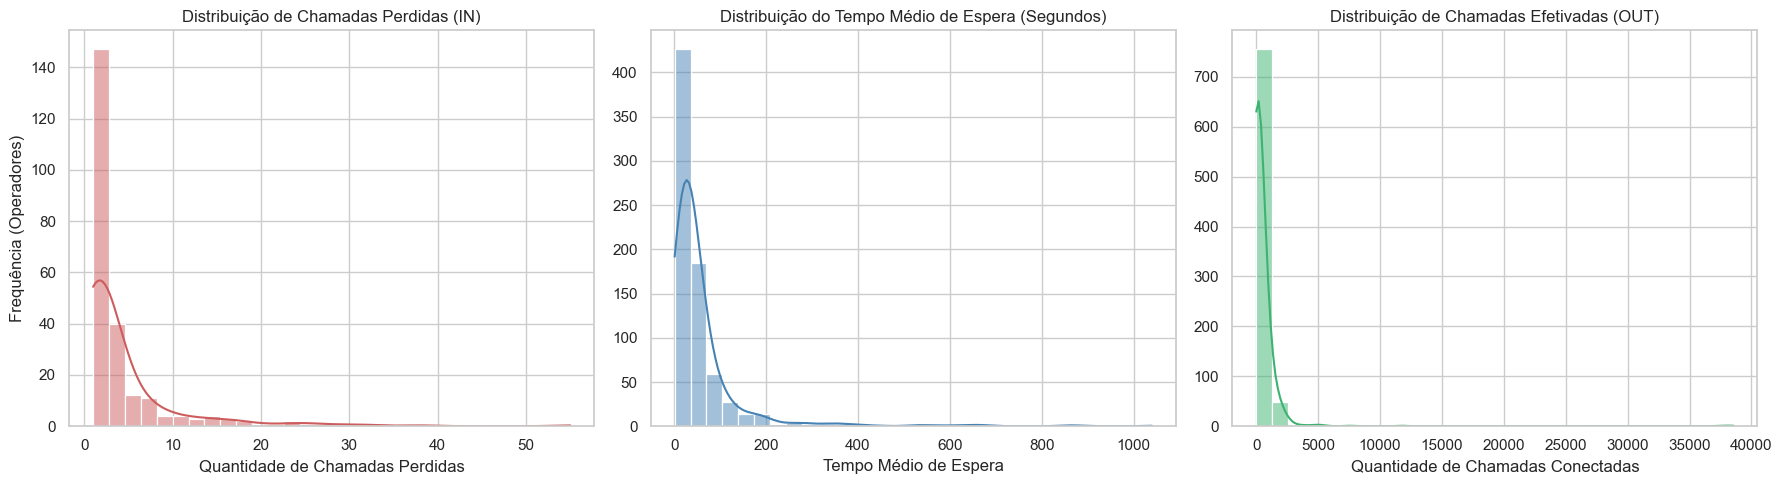

--- Limiares de Ineficiência Definidos ---
1. Será ineficiente se perder mais que: 11 chamadas.
2. Será ineficiente se o tempo médio de espera for maior que: 114.49 segundos.
3. Será ineficiente se efetuar menos que: 2 chamadas ativas (para operadores de outbound).


In [18]:
# Visualização das Distribuições dos KPIs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_palette("muted")

# Gráfico 1: Chamadas Perdidas (Recebidas)
sns.histplot(df_operators[df_operators['missed_in_calls'] > 0]['missed_in_calls'], bins=30, ax=axes[0], kde=True, color='indianred')
axes[0].set_title('Distribuição de Chamadas Perdidas (IN)')
axes[0].set_xlabel('Quantidade de Chamadas Perdidas')
axes[0].set_ylabel('Frequência (Operadores)')

# Gráfico 2: Tempo de Espera
sns.histplot(df_operators[df_operators['avg_waiting_time_in'] > 0]['avg_waiting_time_in'], bins=30, ax=axes[1], kde=True, color='steelblue')
axes[1].set_title('Distribuição do Tempo Médio de Espera (Segundos)')
axes[1].set_xlabel('Tempo Médio de Espera')
axes[1].set_ylabel('')

# Gráfico 3: Produtividade (Chamadas Realizadas)
# Filtramos apenas quem tem > 0 para analisar quem de fato faz ligações de saída
sns.histplot(df_operators[df_operators['connected_out_calls'] > 0]['connected_out_calls'], bins=30, ax=axes[2], kde=True, color='mediumseagreen')
axes[2].set_title('Distribuição de Chamadas Efetivadas (OUT)')
axes[2].set_xlabel('Quantidade de Chamadas Conectadas')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# Calculando os Limiares (Thresholds) de Ineficiência
# Vamos usar quantis para encontrar a linha de corte justa baseada nos dados
threshold_missed = df_operators[df_operators['missed_in_calls'] > 0]['missed_in_calls'].quantile(0.90)
threshold_wait = df_operators[df_operators['avg_waiting_time_in'] > 0]['avg_waiting_time_in'].quantile(0.90)
threshold_out = df_operators[df_operators['connected_out_calls'] > 0]['connected_out_calls'].quantile(0.10)

print(f"--- Limiares de Ineficiência Definidos ---")
print(f"1. Será ineficiente se perder mais que: {threshold_missed:.0f} chamadas.")
print(f"2. Será ineficiente se o tempo médio de espera for maior que: {threshold_wait:.2f} segundos.")
print(f"3. Será ineficiente se efetuar menos que: {threshold_out:.0f} chamadas ativas (para operadores de outbound).")


## 6. Identificação Final dos Operadores Ineficientes

Com os nossos limiares (*thresholds*) matematicamente definidos, podemos agora classificar cada operador da nossa base. 

Para atender ao requisito de automação e deixar o código escalável (caso a empresa passe a processar milhões de linhas no futuro próximo), criaremos uma função que testa os três critérios de ineficiência para cada operador.

**Regras aplicadas:**
1. `missed_in_calls` > Limite de Perdas (11)
2. `avg_waiting_time_in` > Limite de Espera (114.49s)
3. `connected_out_calls` < Limite de Produtividade (2) *(Nota: Esta regra só será aplicada a operadores que registraram atividade de saída, para não penalizarmos operadores que trabalham 100% no receptivo)*.

Se o operador falhar em **qualquer um** desses critérios, ele receberá a *flag* de ineficiente.


In [19]:
# 6.1 Criando a função que automatiza o processo de classificação
def identificar_ineficiencia(row, t_missed, t_wait, t_out):
    """
    Classifica um operador como ineficiente (True) ou eficiente (False)
    com base nos thresholds calculados.
    
    row: linha do DataFrame que será analisada
    t_missed: Threshold de chamadas perdidas
    t_wait: Threshold de tempo de espera
    t_out: Threshold de chamadas ativas
    """
    # Critério 1: Muitas chamadas recebidas perdidas
    if row['missed_in_calls'] > t_missed:
        return True
    
    # Critério 2: Tempo de espera prolongado
    elif row['avg_waiting_time_in'] > t_wait:
        return True
    
    # Critério 3: Poucas chamadas ativas (apenas para quem tem perfil de saída)
    # Consideramos "perfil de saída" quem registrou mais de 0 chamadas conectadas, mas ficou abaixo do limiar (ex: fez apenas 1 chamada).
    elif (row['connected_out_calls'] > 0) and (row['connected_out_calls'] < t_out):
        return True
    
    # Se não caiu em nenhuma das regras acima, o operador é eficiente
    else:
        return False

# 6.2 Aplicando a função no DataFrame inteiro de uma só vez
df_operators['is_inefficient'] = df_operators.apply(
    lambda x: identificar_ineficiencia(x, threshold_missed, threshold_wait, threshold_out), 
    axis=1
)

# 6.3 Resumo dos Resultados
total_operadores = len(df_operators)
ineficientes_count = df_operators['is_inefficient'].sum()

print("--- DIAGNÓSTICO FINAL DE EFICIÊNCIA ---")
print(f"Total de operadores analisados: {total_operadores}")
print(f"Operadores classificados como INEFICIENTES: {ineficientes_count} ({(ineficientes_count/total_operadores)*100:.2f}%)")

# Criando um DataFrame apenas com os ineficientes para entregar aos stakeholders
df_stakeholder_report = df_operators[df_operators['is_inefficient'] == True].sort_values(by='missed_in_calls', ascending=False)

print("\n--- Top 5 Operadores Mais Críticos ---")
display(df_stakeholder_report.head())


--- DIAGNÓSTICO FINAL DE EFICIÊNCIA ---
Total de operadores analisados: 1092
Operadores classificados como INEFICIENTES: 133 (12.18%)

--- Top 5 Operadores Mais Críticos ---


,operator_id,missed_in_calls,avg_waiting_time_in,connected_out_calls,is_inefficient
346,913942,55.0,350.86,298.0,True
763,944226,38.0,163.89,110.0,True
766,944216,32.0,163.03,116.0,True
984,940588,30.0,125.31,46.0,True
87,885890,27.0,120.34,38539.0,True


**Observações:** A aplicação dos nossos limiares matemáticos resultou em **133 operadores classificados como ineficientes**, o que representa **12,18%** da nossa base ativa. Esse número confirma a eficácia do nosso método baseado em percentis, pois conseguimos isolar a minoria crítica sem penalizar a grande maioria (88%) que atua dentro da normalidade.

Analisando o Top 5 de operadores mais críticos, destacam-se duas observações importantes para o negócio:

1. **Casos Críticos de Espera:** O operador `913942` apresenta números alarmantes. Além de perder 55 chamadas, seu tempo médio de espera é superior a 350 segundos (quase 6 minutos). Esse é um candidato imediato para retreinamento ou revisão de infraestrutura.
2. **Possível Desvio de Função ou Automação:** O operador `885890` foi classificado como ineficiente por suas métricas receptivas (27 chamadas perdidas e tempo de espera alto), porém, ele possui um volume assombroso de **38.539 chamadas de saída**. Esse volume é humanamente impossível para ligações manuais em um curto período, sugerindo que este "operador" pode ser, na verdade, um sistema de discagem automática (Robocall/Bot) ou um setor inteiro mapeado em um único ID. O fato dele estar recebendo ligações e performando mal nelas indica um provável erro de roteamento no sistema da CallMeMaybe.

## 7. Teste de Hipóteses Estatísticas

Para aprofundar nossa análise e gerar ainda mais valor estratégico para a CallMeMaybe, vamos investigar se o comportamento de uso do sistema de telefonia varia de acordo com o plano tarifário contratado pelo cliente (organização). 

A variável que vamos testar será a **duração média das chamadas** (`call_duration`). A escolha dessa métrica se dá porque clientes com chamadas sistematicamente mais longas podem exigir infraestruturas de servidores mais robustas.

### 7.1 Formulação das Hipóteses

Vamos comparar dois grupos de planos tarifários (ex: Plano A vs. Plano B/C). As nossas hipóteses estatísticas são definidas da seguinte forma:

- **Hipótese Nula ($H_0$):** Não há diferença estatisticamente significativa na duração média das chamadas entre os diferentes planos tarifários. (As médias são iguais: $\mu_A = \mu_B$)
- **Hipótese Alternativa ($H_1$):** Existe uma diferença estatisticamente significativa na duração média das chamadas entre os diferentes planos tarifários. (As médias são diferentes: $\mu_A \neq \mu_B$)

***Nota Estratégica**: Ao analisar a base de clientes, observamos que o Plano A é o mais exclusivo por ter menor número de assinantes (somente $76$), enquanto os Planos B ($261$ assinantes) e C ($395$ assinantes) são mais populares. Esses números indicam que o Plano A é um possível perfil Premium. Portanto, optamos por agrupar os Planos B e C (maior volume) em uma única categoria (Planos Base) e compará-los diretamente com o Plano A.*

### 7.2 Metodologia Escolhida

Para validar essas hipóteses, utilizaremos o **Teste T de Student para Amostras Independentes**. 
Este método é o mais adequado para o nosso caso porque:
1. Estamos comparando as médias de dois grupos distintos e independentes (um cliente não pode ter dois planos ativos simultaneamente).
2. Nossa amostra é grande o suficiente (centenas/milhares de chamadas), o que pelo Teorema do Limite Central nos permite assumir a normalidade da distribuição das médias.

Estabeleceremos um nível de significância (alfa) de **$\alpha = 0.05$ (5%)**. Isso significa que se o valor-p (p-value) resultante do teste for menor que 0.05, rejeitaremos a Hipótese Nula a favor da Alternativa.


In [21]:
# Verificando quais são e quantos são os planos tarifários contratados
print("--- Distribuição dos Planos Tarifários ---")
display(df_clients['tariff_plan'].value_counts())

--- Distribuição dos Planos Tarifários ---


tariff_plan
C    395
B    261
A     76
Name: count, dtype: int64